# Análisis exploratorio de datos | Datos históricos del precio del Bitcoin



## Introducción y contexto
### Objetivo del análisis

#### Objetivo general
- Comprender la estructura y características generales de la serie histórica de precios del bitcoin.

#### Objetivos específicos
- Deescribir las principales caracteristicas del conjunto de datos como su estructura, dimensiones, datos faltantes buscando identificar mediante el análisis de funciones de autocorrelación y agrupaciones temporales las frecuencias más dominantes.
- Analizar la tendencia a largo plazo de la serie, aplicando métodos de suavizamineto, pruebas de estacionariedad y transformaciones de datos para corregir cambios en la media y varianza en el timepo
- Examinar anomalias o eventos extremos contextualizacion los posibles eventos externos relevantes
- Sintetizar los resultados más relevantes y las problemáticas detectadas construyendo recomendaciones para la siguiente fase del proyecto.

### Descripción de los datos
El Bitcoin es una criptomoneda descentralizada nacida en el año 2008 por una entidad conocida como Satoshi Nakamoto. Su principal diferenciador frente a las monedas tradicionales y reguladas, es el uso de blockchain para poder realizar transferencias bancarias sin necesidad de tener un intermediario financiero. Su popularidad de debe a su alta volatilidad, alzas astronómicas en su valor durante la pandemia, una oferta limitada de 21 millones de unidades, e inmediatez en las transacciones globales.
El conjunto de datos escogido para ser utilizados en este proyecto es titulado "Bitcoin Historical Data" y fue publicado en la Kaggle, una de las comunidades para cientificos de datos más populares en todo el mundo. El dataset presenta una serie temporal que describe desde el año 2012 el precio registrado del bitcoin frente al dólar estadounidense registrado por minuto, lo cual permite explorar con mucha granularidad el comportamiento de la serie. Adicionalmente, resulta importante mencionar qué variables ayudan a describir los datos:

- Open: Precio de apertura
- High: Precio máximo en una ventana de tiempo 
- Low: Precio minimo en una ventana de tiempo 
- Close: Precio de cierre
- Volume: Volumen de BTC transaccionado en la ventana de tiempo 

Resulta importante resaltar que los precios están expresados en dólares estadounidenses (USD) y el volumen representa la cantidad de Bitcoin negociada (BTC). 

## Análisis preliminar

### Inspección general
#### Dimensiones del conjunto de datos
Primero, se revisa la dimensión general del dataset. Este paso resulta relevante para poder establecer la complejidad computacional del ejercico

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/pctm/Desktop/Universidad/Sem 6/btcusd_1-min_data.csv')
pd.options.display.float_format = '{:,.2f}'.format
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7457440 entries, 0 to 7457439
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 341.4 MB
None


Como vemos, el presente dataset cuenta con 7.457.440 observaciones descritas con la ayuda de 6 variables:
- **Timestamp**: Contiene información sobre la ventana de tiempo referencia de cada observación.
- **Open**: Precio de apertura
- **High**: Precio máximo en una ventana de tiempo 
- **Low**: Precio minimo en una ventana de tiempo 
- **Close**: Precio de cierre
- **Volume**: Volumen de BTC transaccionado en la ventana de tiempo 

#### Primeros y ultimos valores
A continuación se procede a revisar los primeros y ultimos registros para verificar la coherencia temporal

In [31]:
print(df.head())
print(df.tail())

         Timestamp  Open  High  Low  Close  Volume
0 1,325,412,060.00  4.58  4.58 4.58   4.58    0.00
1 1,325,412,120.00  4.58  4.58 4.58   4.58    0.00
2 1,325,412,180.00  4.58  4.58 4.58   4.58    0.00
3 1,325,412,240.00  4.58  4.58 4.58   4.58    0.00
4 1,325,412,300.00  4.58  4.58 4.58   4.58    0.00
               Timestamp      Open      High       Low     Close  Volume
7457435 1,772,927,760.00 67,275.00 67,283.00 67,268.00 67,268.00    0.96
7457436 1,772,927,820.00 67,269.00 67,281.00 67,268.00 67,281.00    0.67
7457437 1,772,927,880.00 67,281.00 67,286.00 67,281.00 67,286.00    0.49
7457438 1,772,927,940.00 67,285.00 67,285.00 67,268.00 67,269.00    0.64
7457439 1,772,928,000.00 67,269.00 67,308.00 67,269.00 67,308.00    0.54


Se puede ver que la variable tiempo está almacenada en formato de timestamp Unix, para mejorar la claridad del análisis se añadirá una nueva columna llamada TimestampConventional con un formato de fecha y hora más legible.

In [32]:
df["TimestampConventional"] = pd.to_datetime(df["Timestamp"], unit="s")

print(df.head())
print(df.tail())

         Timestamp  Open  High  Low  Close  Volume TimestampConventional
0 1,325,412,060.00  4.58  4.58 4.58   4.58    0.00   2012-01-01 10:01:00
1 1,325,412,120.00  4.58  4.58 4.58   4.58    0.00   2012-01-01 10:02:00
2 1,325,412,180.00  4.58  4.58 4.58   4.58    0.00   2012-01-01 10:03:00
3 1,325,412,240.00  4.58  4.58 4.58   4.58    0.00   2012-01-01 10:04:00
4 1,325,412,300.00  4.58  4.58 4.58   4.58    0.00   2012-01-01 10:05:00
               Timestamp      Open      High       Low     Close  Volume  \
7457435 1,772,927,760.00 67,275.00 67,283.00 67,268.00 67,268.00    0.96   
7457436 1,772,927,820.00 67,269.00 67,281.00 67,268.00 67,281.00    0.67   
7457437 1,772,927,880.00 67,281.00 67,286.00 67,281.00 67,286.00    0.49   
7457438 1,772,927,940.00 67,285.00 67,285.00 67,268.00 67,269.00    0.64   
7457439 1,772,928,000.00 67,269.00 67,308.00 67,269.00 67,308.00    0.54   

        TimestampConventional  
7457435   2026-03-07 23:56:00  
7457436   2026-03-07 23:57:00  
7457437  

Luego de la conversión, se puede ver que el inicio de la recopilación de los datos comienza desde el primero de enero del año 2012, mientras el último registro coincide con el 7 de marzo.

#### Identificación de valores faltantes
Finalmente, en esta sección se revisarán los valores faltantes de la serie.

In [33]:
print(df.isnull().sum())

print(df.isnull().mean()*100)


Timestamp                0
Open                     0
High                     0
Low                      0
Close                    0
Volume                   0
TimestampConventional    0
dtype: int64
Timestamp               0.00
Open                    0.00
High                    0.00
Low                     0.00
Close                   0.00
Volume                  0.00
TimestampConventional   0.00
dtype: float64


Como vemos, no existen valores faltantes en esta serie temporal.

### Inspección general
#### Medidas básicas
Se procederá a conocer las medidas descriptivas básicas del conjunto de datos con el objetivo de tener una primera aproximación al mercado de Bitcoin durante el periodo analizado. Estas incluyen: media, mediana, desviación estándar, minimo, máximo y percentiles.

In [34]:
cols = ["Open","High","Low","Close","Volume"]
print(df[cols].describe().T)

              count      mean       std  min    25%      50%       75%  \
Open   7,457,440.00 22,393.14 30,806.45 3.80 449.00 7,546.00 34,679.33   
High   7,457,440.00 22,401.11 30,814.85 3.80 449.12 7,549.04 34,697.00   
Low    7,457,440.00 22,384.98 30,797.98 3.80 448.91 7,541.96 34,661.00   
Close  7,457,440.00 22,393.15 30,806.47 3.80 449.00 7,546.19 34,680.00   
Volume 7,457,440.00      5.08     21.88 0.00   0.02     0.45      2.87   

              max  
Open   126,202.00  
High   126,272.00  
Low    126,158.00  
Close  126,202.00  
Volume   5,853.85  


Se puede ver que las variables de precio Open, High, Low y Close presentan valores promedio cercanos a 22.000 USD con una desviación estándar aproximada de 30.000 USD, lo cual podría indicar una alta volatilidad en su precio en el transcurso de los años. El valor minimo registrado corresponde a 3.80 dólares y su máximo a 126.000 dólares. Incluso los percentiles coinciden, con un 25% de los precios menores a 449 USD y un 75% por debajo de 34.690 dólares. La mediana o el 50% de los datos se sitúa cerca a 7.500 USD.

Por otro lado, para la variable Volume, se tiene una media de aproximadamente 5.08, con una desviación estándar de 21.88. Presenta valores mínimos cercanos a 0 y máximos que superan 5,800, lo cual indica la posible presencia de periodos con actividad de mercado mucho más alta. La mediana de los datos se encuentra en 0.45. 

#### Métricas de dispersión 
Para profundizar el análisis se procederá a calcular el rango intercuartilico con el objetivo de medir la dispersión de los valores centrales de la distribución.

In [35]:
cols = ["Open","High","Low","Close","Volume"]

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)

IQR = Q3 - Q1

print(IQR)

Open     34,230.33
High     34,247.88
Low      34,212.09
Close    34,231.00
Volume        2.85
dtype: float64


En el caso de las variables de precio Open, High, Low y Close se puede observar que el valor del rango intercuartilico es aproximadamente de 34.000 USD, lo cual confirma una alta volatilidad de su precio a lo largo del tiempo. Por otro lado, el Volume tiene un IQR de 2.85 que al compararse con su valor máximo, podría interpretarse como un rango reducido, con una presencia de valores extremos o picos de actividad.

## Visualización de la serie

### Visualización temporal
#### Gráfica de linea
A continuación, se procederá a construir la primera visualización de la serie.

In [36]:
print(df.columns)

Index(['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume',
       'TimestampConventional'],
      dtype='object')


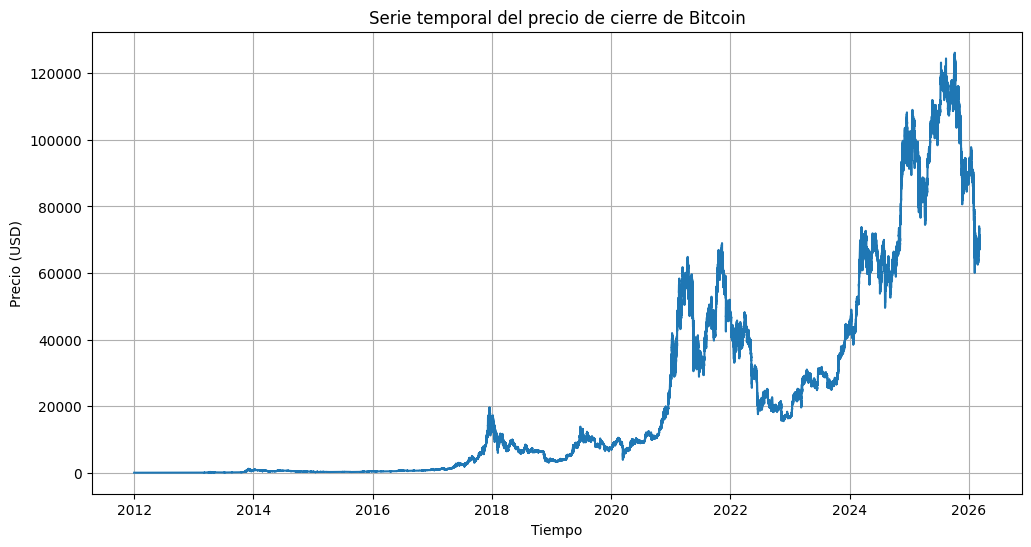

In [38]:
df['TimestampConventional'] = pd.to_datetime(df['TimestampConventional'], unit='s')
df = df.sort_values('TimestampConventional')

plt.figure(figsize=(12,6))

plt.plot(df['TimestampConventional'], df['Close'])

plt.title("Serie temporal del precio de cierre de Bitcoin")
plt.xlabel("Tiempo")
plt.ylabel("Precio (USD)")
plt.grid(True)

plt.show()

Este gráfico presenta la evolución general del precio de cierre del Bitcoin frente al dolar desde su inicio en el año 2012. Se puede ver que hubo un aumento considerable de su precio desde el año 2020, hasta llegar a su máximo histórico a finales del año 2025. Posteriormente se ha visto una correción de su precio, reflejando la volatilidad característica del mercado de criptomonedas.

#### Gráfica desagregada
#### Precios

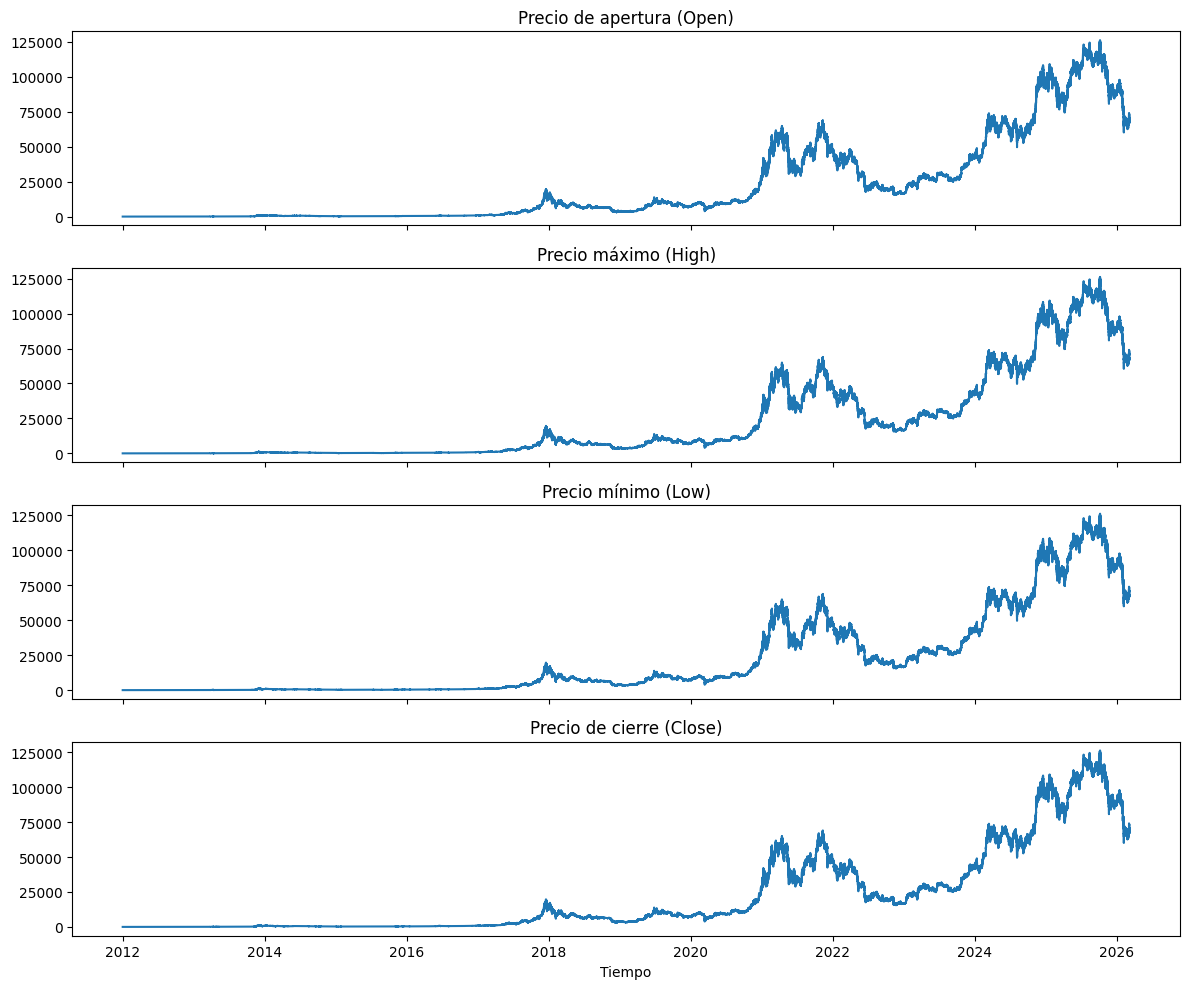

In [39]:
fig, axes = plt.subplots(4,1, figsize=(12,10), sharex=True)

axes[0].plot(df['TimestampConventional'], df['Open'])
axes[0].set_title("Precio de apertura (Open)")

axes[1].plot(df['TimestampConventional'], df['High'])
axes[1].set_title("Precio máximo (High)")

axes[2].plot(df['TimestampConventional'], df['Low'])
axes[2].set_title("Precio mínimo (Low)")

axes[3].plot(df['TimestampConventional'], df['Close'])
axes[3].set_title("Precio de cierre (Close)")

plt.xlabel("Tiempo")
plt.tight_layout()
plt.show()

Las series correspondientes al precio de apertura, máximo, mínimo y cierre presentan comportamientos extremadamente similares al tratarse del mismo activo en un intervalo temporal muy corto. Se ven las mismas tendencias y eventualidades descritas previamente.

#### Volumen

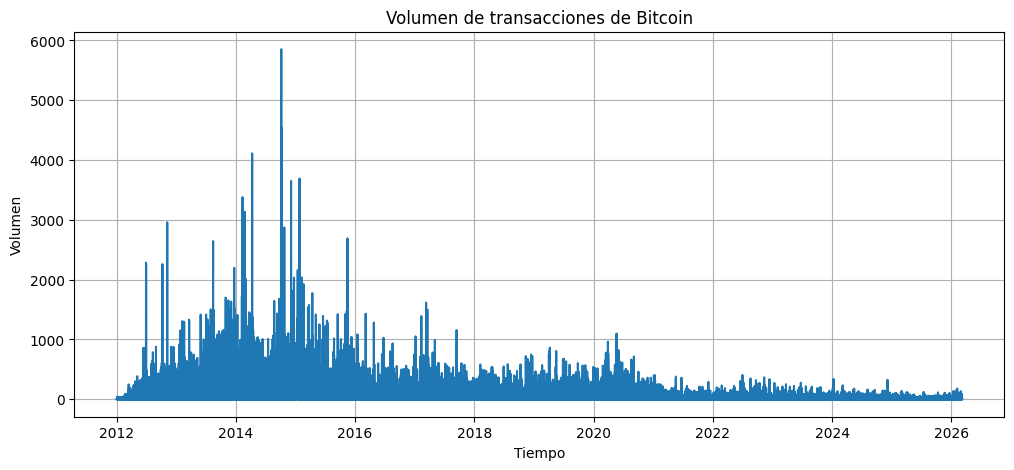

In [40]:
plt.figure(figsize=(12,5))

plt.plot(df['TimestampConventional'], df['Volume'])

plt.title("Volumen de transacciones de Bitcoin")
plt.xlabel("Tiempo")
plt.ylabel("Volumen")
plt.grid(True)

plt.show()

Por otro lado, el volumen presenta un comportamiento distinto a las demás variables con picos de gran volumen entre 2013 y 2016, lo cual podría hacer referencia a altos picos de actividad en ese periodo de tiempo. Esto se ve seguido a una disminución en los años 2017 y 2018, mientras que a partir de 2020, el volumen es mucho más bajo y estable.